In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [2]:
project_root = Path("/home/akapociu/ift/interactiondynamics")
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from data.spring_ring import SpringRing2DConfig, SpringRing2DDataset

In [3]:
cfg = SpringRing2DConfig(
    num_nodes=32,
    num_bins=256,
    force_threshold=0.0,   # set to 0 so we can inspect essentially all ring edges
    bidirectional=True,
    seed=0,
)

ds = SpringRing2DDataset(cfg)
spec = ds.spec()
spec

DataSpec(name='spring_ring_2d', num_nodes=32, event_dim=8, num_events=16384, num_bins=256, extra={'node_target_dim': 2, 'node_target_names': ['dvx', 'dvy']})

In [4]:
batch0 = next(iter(ds.bins("train")))
print(batch0.src[:10])
print(batch0.dst[:10])
print(batch0.features.shape if batch0.features is not None else None)
print(spec)

tensor([0, 1, 1, 2, 2, 3, 3, 4, 4, 5])
tensor([1, 0, 2, 1, 3, 2, 4, 3, 5, 4])
torch.Size([64, 8])
DataSpec(name='spring_ring_2d', num_nodes=32, event_dim=8, num_events=16384, num_bins=256, extra={'node_target_dim': 2, 'node_target_names': ['dvx', 'dvy']})


THRESHOLD OPTIONS FOR SPRING RING:

The spring-ring dataset emits an edge when the spring force magnitude is above
`force_threshold`.

Stored edge features are:
- dx, dy     : relative displacement vector
- dvx, dvy   : relative velocity vector
- dist       : current spring length
- extension  : dist - rest_length
- fx, fy     : spring force vector components

The actual thresholded quantity in the dataset is:

    force_mag = sqrt(fx^2 + fy^2)

so if we want percentiles for the spring-ring threshold, we should compute
percentiles of `force_mag`, not wave metrics like `pair_accel_contrib`.

- For every emitted ring edge in every bin of the chosen split, we compute the
  force magnitude from the stored force components:
      force_mag = sqrt(fx^2 + fy^2)

- Then we summarize its distribution and report percentile cutoffs.

- Those percentile values are the natural candidates for choosing
  `SpringRing2DConfig(force_threshold=...)`.

- The "kept/bin" section below estimates how many edges would survive if you set
  `force_threshold` equal to each percentile cutoff.

feature_idx: {'dx': 0, 'dy': 1, 'dvx': 2, 'dvy': 3, 'dist': 4, 'extension': 5, 'fx': 6, 'fy': 7}
num bins inspected: 38
edges per bin (first few): [64, 64, 64, 64, 64, 64, 64, 64, 64, 64]
mean edges/bin: 64.00

=== force_mag ===
count: 2432
min:   3.93391e-06
mean:  0.0319594
std:   0.0235531
max:   0.113519
p50:   0.0275852
p75:   0.0422165
p90:   0.0685315
p95:   0.0827587
p99:   0.0983722


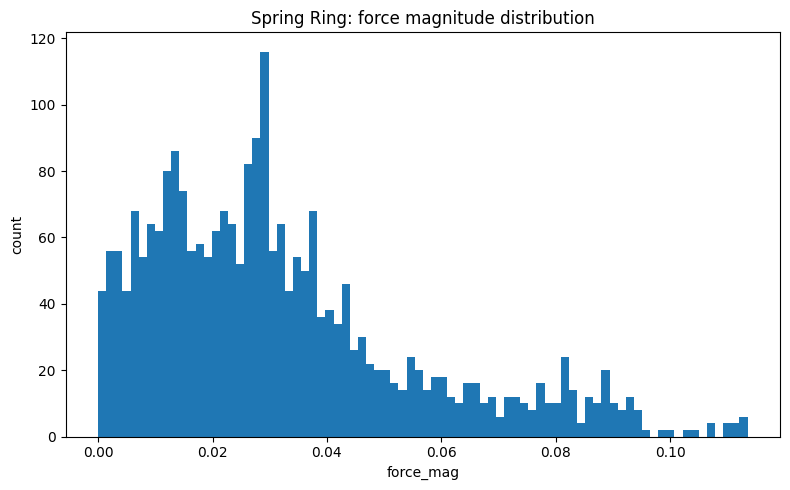


=== Estimated sparsity by percentile cutoff for force_threshold ===
p50 threshold = 0.0275852 | mean kept/bin = 32.00 | median = 34.00 | min = 24 | max = 40
p75 threshold = 0.0422165 | mean kept/bin = 16.00 | median = 16.00 | min = 6 | max = 24
p90 threshold = 0.0685315 | mean kept/bin = 6.42 | median = 6.00 | min = 2 | max = 12
p95 threshold = 0.0827587 | mean kept/bin = 3.21 | median = 4.00 | min = 0 | max = 8
p99 threshold = 0.0983722 | mean kept/bin = 0.68 | median = 0.00 | min = 0 | max = 2


In [5]:
# -----------------------------
# config
# -----------------------------
split = "val"          # or "train" / "val" / "test"
percentiles = [50, 75, 90, 95, 99]

# -----------------------------
# spring ring feature layout
# must match data.spring_ring.SpringRing2DDataset
# [dx, dy, dvx, dvy, dist, extension, fx, fy]
# -----------------------------
feature_names = ["dx", "dy", "dvx", "dvy", "dist", "extension", "fx", "fy"]
feature_idx = {name: i for i, name in enumerate(feature_names)}
print("feature_idx:", feature_idx)

# -----------------------------
# collect per-bin values
# -----------------------------
force_mag_all = []
force_mag_by_bin = []
edges_per_bin = []

for batch in ds.bins(split):
    if batch.features is None:
        continue

    feats = batch.features.detach().cpu().numpy()   # [num_edges, 8]
    edges_per_bin.append(feats.shape[0])

    fx = feats[:, feature_idx["fx"]]
    fy = feats[:, feature_idx["fy"]]
    force_mag = np.sqrt(fx**2 + fy**2)

    force_mag_all.append(force_mag)
    force_mag_by_bin.append(force_mag)

print(f"num bins inspected: {len(edges_per_bin)}")
print(f"edges per bin (first few): {edges_per_bin[:10]}")
print(f"mean edges/bin: {np.mean(edges_per_bin):.2f}")

force_mag_all = np.concatenate(force_mag_all) if force_mag_all else np.array([])

# -----------------------------
# summary stats
# -----------------------------
print("\n=== force_mag ===")
print(f"count: {len(force_mag_all)}")
print(f"min:   {force_mag_all.min():.6g}")
print(f"mean:  {force_mag_all.mean():.6g}")
print(f"std:   {force_mag_all.std():.6g}")
print(f"max:   {force_mag_all.max():.6g}")
for p in percentiles:
    print(f"p{p}:   {np.percentile(force_mag_all, p):.6g}")

# -----------------------------
# histogram
# -----------------------------
plt.figure(figsize=(8, 5))
plt.hist(force_mag_all, bins=80)
plt.title("Spring Ring: force magnitude distribution")
plt.xlabel("force_mag")
plt.ylabel("count")
plt.tight_layout()
plt.show()

# -----------------------------
# survival counts by percentile threshold
# note: dataset code uses force_mag > force_threshold
# here >= is fine for percentile estimation; ties are usually negligible
# -----------------------------
print("\n=== Estimated sparsity by percentile cutoff for force_threshold ===")
for p in percentiles:
    thr = np.percentile(force_mag_all, p)

    kept_counts = []
    for vals_bin in force_mag_by_bin:
        kept = (vals_bin >= thr).sum()
        kept_counts.append(int(kept))

    kept_counts = np.array(kept_counts)

    print(
        f"p{p:>2} threshold = {thr:.6g} | "
        f"mean kept/bin = {kept_counts.mean():.2f} | "
        f"median = {np.median(kept_counts):.2f} | "
        f"min = {kept_counts.min()} | "
        f"max = {kept_counts.max()}"
    )

In [6]:
from collections import Counter

split = "val"

edge_counts = []
for batch in ds.bins(split):
    n_edges = int(batch.src.numel())
    edge_counts.append(n_edges)

edge_counts = np.array(edge_counts)

print(f"=== Edge count stats for split={split!r} ===")
print(f"num_bins:         {len(edge_counts)}")
print(f"total_edges:      {edge_counts.sum()}")
print(f"min_edges/bin:    {edge_counts.min()}")
print(f"max_edges/bin:    {edge_counts.max()}")
print(f"mean_edges/bin:   {edge_counts.mean():.2f}")
print(f"median_edges/bin: {np.median(edge_counts):.2f}")
print(f"std_edges/bin:    {edge_counts.std():.2f}")
print(f"first 10 bins:    {edge_counts[:10].tolist()}")

count_freq = Counter(edge_counts.tolist())

print("\n=== Bin count frequency ===")
for edge_count in sorted(count_freq):
    print(f"{count_freq[edge_count]} bins have {edge_count} edges")

=== Edge count stats for split='val' ===
num_bins:         38
total_edges:      2432
min_edges/bin:    64
max_edges/bin:    64
mean_edges/bin:   64.00
median_edges/bin: 64.00
std_edges/bin:    0.00
first 10 bins:    [64, 64, 64, 64, 64, 64, 64, 64, 64, 64]

=== Bin count frequency ===
38 bins have 64 edges
